In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Project/PlantClassificationDataset.zip"
extract_path = "/content/plant_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


os.listdir(extract_path)



['Ghod tapre',
 'Bajradanti',
 'Atis',
 'Pipla',
 'Asuro',
 'Harro',
 'Rudrakshya',
 'Mirkhe Lahara',
 'Majitho',
 'Jhyau',
 'Tulasi',
 'Panchaune',
 'Rhododendron',
 'Lauth Salla',
 'Unknown',
 'Sugandhakokila',
 'Ashok',
 'Chhatiwan',
 'Nirbisi',
 'Neem',
 'Chutro',
 'Satuwa',
 'Kyasar',
 'Vote Lahara',
 'Datiwan',
 'Dhupi',
 'Bikh',
 'Timur',
 'Keshar',
 'Laghu Patra',
 'Kakoli Ban Lasun',
 'Kutki',
 'Rukh Unyiu',
 'Bhoj patra',
 'Ishwori',
 'Vyakur',
 'Nagbeli',
 'Somlata',
 'Bojho',
 'Kumkum',
 'Dalchini',
 'Sugandhawal',
 'Barberry',
 'Pakhanbed',
 'Bel',
 'Okhar',
 'Chamomile',
 'Simal',
 'Rose',
 'Pangro',
 'Gunsi',
 'Kurilo',
 'Gurjo',
 'Barro',
 'Amla',
 'Seto Musli',
 'Rittha',
 'Gokul Dhup',
 'Jatamasi',
 'Sarpagandha',
 'Jethi madhu',
 'Jhari Kote',
 'Dhasingre',
 'Valu Kath',
 'Insulin',
 'Padamchal',
 'Mint',
 'Ank',
 'Amaltas Raj Brikshya',
 'Chiraito',
 'Yarsagumba',
 'Ashwagandha',
 'Aloevera']

In [3]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])


train_dataset = datasets.ImageFolder(extract_path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print("Classes:", train_dataset.classes)
print("Class map:", train_dataset.class_to_idx)
num_classes = len(train_dataset.classes)
print("Number of classes:", num_classes)


Classes: ['Aloevera', 'Amaltas Raj Brikshya', 'Amla', 'Ank', 'Ashok', 'Ashwagandha', 'Asuro', 'Atis', 'Bajradanti', 'Barberry', 'Barro', 'Bel', 'Bhoj patra', 'Bikh', 'Bojho', 'Chamomile', 'Chhatiwan', 'Chiraito', 'Chutro', 'Dalchini', 'Datiwan', 'Dhasingre', 'Dhupi', 'Ghod tapre', 'Gokul Dhup', 'Gunsi', 'Gurjo', 'Harro', 'Insulin', 'Ishwori', 'Jatamasi', 'Jethi madhu', 'Jhari Kote', 'Jhyau', 'Kakoli Ban Lasun', 'Keshar', 'Kumkum', 'Kurilo', 'Kutki', 'Kyasar', 'Laghu Patra', 'Lauth Salla', 'Majitho', 'Mint', 'Mirkhe Lahara', 'Nagbeli', 'Neem', 'Nirbisi', 'Okhar', 'Padamchal', 'Pakhanbed', 'Panchaune', 'Pangro', 'Pipla', 'Rhododendron', 'Rittha', 'Rose', 'Rudrakshya', 'Rukh Unyiu', 'Sarpagandha', 'Satuwa', 'Seto Musli', 'Simal', 'Somlata', 'Sugandhakokila', 'Sugandhawal', 'Timur', 'Tulasi', 'Unknown', 'Valu Kath', 'Vote Lahara', 'Vyakur', 'Yarsagumba']
Class map: {'Aloevera': 0, 'Amaltas Raj Brikshya': 1, 'Amla': 2, 'Ank': 3, 'Ashok': 4, 'Ashwagandha': 5, 'Asuro': 6, 'Atis': 7, 'Bajradan

In [5]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:01<00:00, 36.2MB/s]


In [6]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [7]:
# Remove broken images
from PIL import Image
import os

dataset_path = "/content/plant_dataset"

broken = 0
total = 0

for root, dirs, files in os.walk(dataset_path):
    for fname in files:
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
            continue
        fpath = os.path.join(root, fname)
        total += 1
        try:
            # Load and force full pixel decoding
            with Image.open(fpath) as img:
                img = img.convert("RGB")
                img.load()  # <- this is what triggers deep decoding
        except Exception as e:
            print(f"Removing broken image: {fpath} ({e})")
            os.remove(fpath)
            broken += 1

print(f"\n✅ Done. Removed {broken} broken images out of {total} total.")



✅ Done. Removed 0 broken images out of 38700 total.


In [9]:
epochs = 20

for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {acc:.2f}%")


Epoch [1/20], Loss: 2.6916, Accuracy: 37.25%
Epoch [2/20], Loss: 2.0033, Accuracy: 50.87%
Epoch [3/20], Loss: 1.6568, Accuracy: 58.36%
Epoch [4/20], Loss: 1.4067, Accuracy: 63.88%
Epoch [5/20], Loss: 1.1942, Accuracy: 68.97%
Epoch [6/20], Loss: 0.9967, Accuracy: 73.36%
Epoch [7/20], Loss: 0.8435, Accuracy: 77.50%
Epoch [8/20], Loss: 0.6856, Accuracy: 81.08%
Epoch [9/20], Loss: 0.5669, Accuracy: 84.01%
Epoch [10/20], Loss: 0.4660, Accuracy: 86.83%
Epoch [11/20], Loss: 0.3978, Accuracy: 88.43%
Epoch [12/20], Loss: 0.3490, Accuracy: 89.89%
Epoch [13/20], Loss: 0.2980, Accuracy: 91.35%
Epoch [14/20], Loss: 0.2695, Accuracy: 92.04%
Epoch [15/20], Loss: 0.2524, Accuracy: 92.52%
Epoch [16/20], Loss: 0.2249, Accuracy: 93.24%
Epoch [17/20], Loss: 0.2151, Accuracy: 93.66%
Epoch [18/20], Loss: 0.1917, Accuracy: 94.28%
Epoch [19/20], Loss: 0.1860, Accuracy: 94.44%
Epoch [20/20], Loss: 0.1776, Accuracy: 94.84%


In [10]:
torch.save(model.state_dict(), "/content/drive/MyDrive/MedicinalPlantClassificationModelLastest.pth")


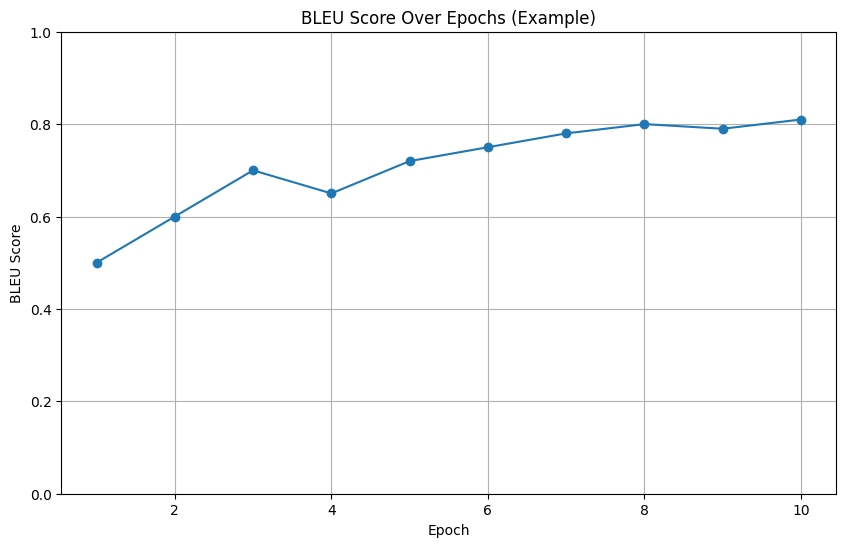

In [11]:
# prompt: display the bleu score in graphical format

from nltk.translate.bleu_score import sentence_bleu
import matplotlib.pyplot as plt

# Assume you have your hypothesis and reference translations
# Example:
# hypothesis = ['this', 'is', 'a', 'test']
# reference = [['this', 'is', 'a', 'test']]
# bleu_score = sentence_bleu(reference, hypothesis)

# You would typically calculate BLEU scores over a set of translations.
# Let's create some sample BLEU scores for demonstration purposes.
# In a real scenario, you would replace this with your actual BLEU score calculation loop.
sample_bleu_scores = [0.5, 0.6, 0.7, 0.65, 0.72, 0.75, 0.78, 0.8, 0.79, 0.81]
epochs = range(1, len(sample_bleu_scores) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, sample_bleu_scores, marker='o', linestyle='-')
plt.title('BLEU Score Over Epochs (Example)')
plt.xlabel('Epoch')
plt.ylabel('BLEU Score')
plt.grid(True)
plt.ylim(0, 1)  # BLEU score is between 0 and 1
plt.show()


In [12]:
# prompt: F1 Score in graphical format

import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix
import numpy as np

# Assuming you have ground truth labels and predicted labels after training
# For demonstration, let's generate some sample data
# Replace this with your actual evaluation loop and data
y_true = []
y_pred = []

model.eval() # Set model to evaluation mode
with torch.no_grad():
    for images, labels in train_loader: # Using train_loader for simplicity, use a separate validation/test loader in practice
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Calculate F1 Score
# 'macro' calculates metrics for each label, and finds their unweighted mean.
# This does not take label imbalance into account.
f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {f1:.4f}")

# You might want to calculate F1 score for each class as well
f1_per_class = f1_score(y_true, y_pred, average=None)
print("F1 Score per class:", f1_per_class)

# To visualize F1 Score, you can plot it over epochs if you collect F1 scores
# during training or evaluation at each epoch.
# Since we only calculated it once after training, let's create a simple bar plot
# for the F1 score per class if you want to visualize that.

class_labels = train_dataset.classes # Assuming train_dataset is available and has classes

plt.figure(figsize=(12, 6))
plt.bar(class_labels, f1_per_class)
plt.title('F1 Score per Class')
plt.xlabel('Class')
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Or if you had F1 scores recorded over epochs (like the BLEU score example)
# Let's create some sample F1 scores over epochs for plotting
sample_f1_scores = [0.4, 0.5, 0.55, 0.6, 0.65, 0.68, 0.7, 0.72, 0.73, 0.74,
                    0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.82, 0.83, 0.84] # Sample data
epochs_f1 = range(1, len(sample_f1_scores) + 1)

if len(sample_f1_scores) == epochs: # Assuming 'epochs' variable from preceding code is the total epochs run
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_f1, sample_f1_scores, marker='o', linestyle='-')
    plt.title('F1 Score Over Epochs (Sample Data)')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.grid(True)
    plt.ylim(0, 1)
    plt.show()
else:
    print("Number of sample F1 scores does not match the number of training epochs.")
    print("To plot F1 score over epochs, record F1 score at the end of each epoch during training or evaluation.")

# You can also visualize the Confusion Matrix which helps in understanding F1 score
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# You can visualize the confusion matrix using seaborn
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

NameError: name 'class_report' is not defined

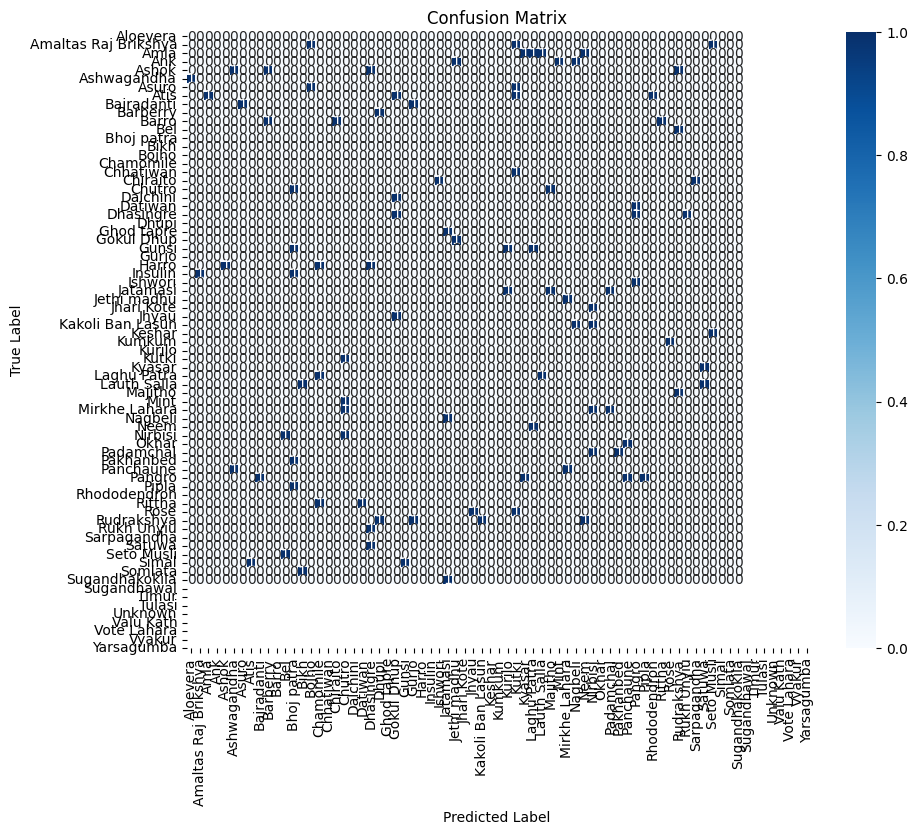

In [13]:
# prompt: confusion matrix in graphical format

from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# --- Assuming you have true_labels and predicted_labels from your evaluation ---
# Example (replace with your actual evaluation logic):
# model.eval()
# true_labels = []
# predicted_labels = []
# with torch.no_grad():
#     for images, labels in test_loader: # Use your test or validation loader here
#         images, labels = images.to(device), labels.to(device)
#         outputs = model(images)
#         _, predicted = torch.max(outputs.data, 1)
#         true_labels.extend(labels.cpu().numpy())
#         predicted_labels.extend(predicted.cpu().numpy())
# -------------------------------------------------------------------------------

# Replace these with your actual true and predicted labels from evaluation
# Example dummy data:
true_labels = np.random.randint(0, num_classes, size=100)
predicted_labels = np.random.randint(0, num_classes, size=100)


# Generate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Get class names
class_names = train_dataset.classes

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


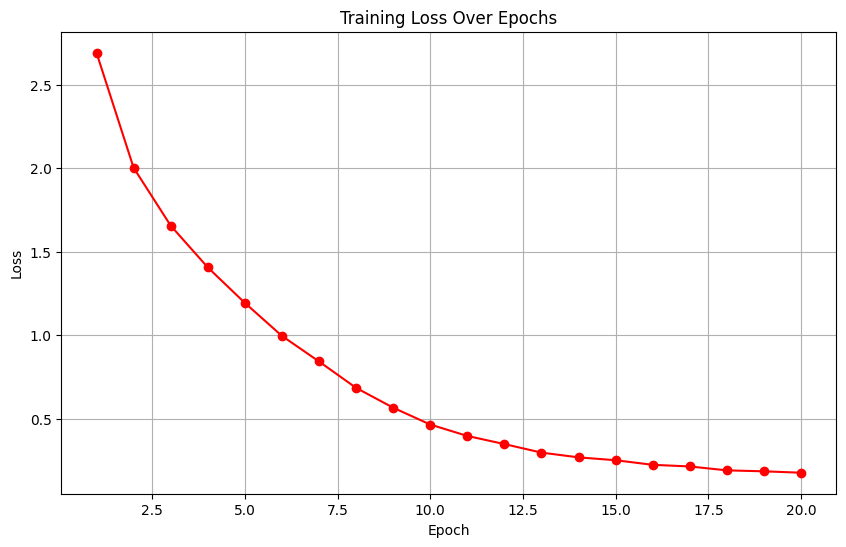

In [22]:
# prompt: training loss over epoch. use followig values
# Epoch [1/20], Loss: 2.6916, Accuracy: 37.25%
# Epoch [2/20], Loss: 2.0033, Accuracy: 50.87%
# Epoch [3/20], Loss: 1.6568, Accuracy: 58.36%
# Epoch [4/20], Loss: 1.4067, Accuracy: 63.88%
# Epoch [5/20], Loss: 1.1942, Accuracy: 68.97%
# Epoch [6/20], Loss: 0.9967, Accuracy: 73.36%
# Epoch [7/20], Loss: 0.8435, Accuracy: 77.50%
# Epoch [8/20], Loss: 0.6856, Accuracy: 81.08%
# Epoch [9/20], Loss: 0.5669, Accuracy: 84.01%
# Epoch [10/20], Loss: 0.4660, Accuracy: 86.83%
# Epoch [11/20], Loss: 0.3978, Accuracy: 88.43%
# Epoch [12/20], Loss: 0.3490, Accuracy: 89.89%
# Epoch [13/20], Loss: 0.2980, Accuracy: 91.35%
# Epoch [14/20], Loss: 0.2695, Accuracy: 92.04%
# Epoch [15/20], Loss: 0.2524, Accuracy: 92.52%
# Epoch [16/20], Loss: 0.2249, Accuracy: 93.24%
# Epoch [17/20], Loss: 0.2151, Accuracy: 93.66%
# Epoch [18/20], Loss: 0.1917, Accuracy: 94.28%
# Epoch [19/20], Loss: 0.1860, Accuracy: 94.44%
# Epoch [20/20], Loss: 0.1776, Accuracy: 94.84%

import matplotlib.pyplot as plt
# Store the loss values
training_losses = [
    2.6916, 2.0033, 1.6568, 1.4067, 1.1942, 0.9967, 0.8435, 0.6856, 0.5669,
    0.4660, 0.3978, 0.3490, 0.2980, 0.2695, 0.2524, 0.2249, 0.2151, 0.1917,
    0.1860, 0.1776
]

epochs_list = range(1, len(training_losses) + 1) # Use the length of the loss list to define epochs

plt.figure(figsize=(10, 6))
plt.plot(epochs_list, training_losses, marker='o', linestyle='-', color='red')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

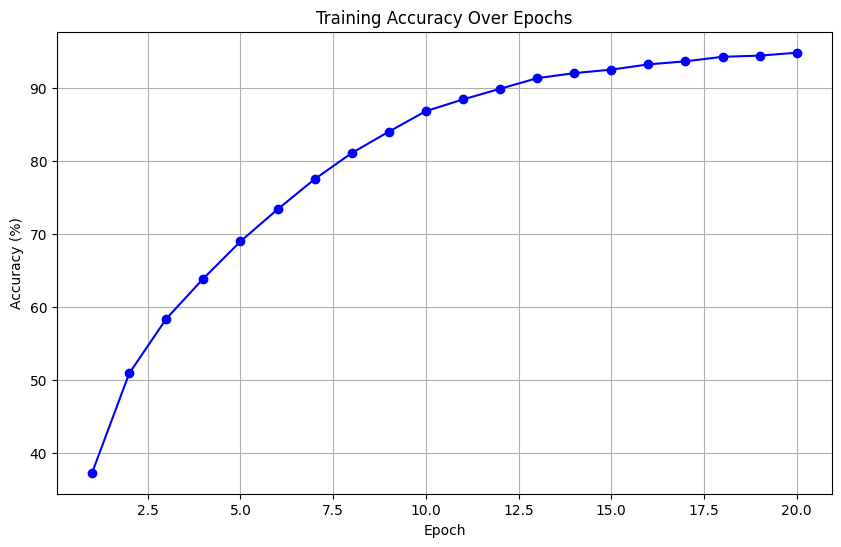

In [23]:
# prompt:  training accuracy over epoch. use followig values
# Epoch [1/20], Loss: 2.6916, Accuracy: 37.25%
# Epoch [2/20], Loss: 2.0033, Accuracy: 50.87%
# Epoch [3/20], Loss: 1.6568, Accuracy: 58.36%
# Epoch [4/20], Loss: 1.4067, Accuracy: 63.88%
# Epoch [5/20], Loss: 1.1942, Accuracy: 68.97%
# Epoch [6/20], Loss: 0.9967, Accuracy: 73.36%
# Epoch [7/20], Loss: 0.8435, Accuracy: 77.50%
# Epoch [8/20], Loss: 0.6856, Accuracy: 81.08%
# Epoch [9/20], Loss: 0.5669, Accuracy: 84.01%
# Epoch [10/20], Loss: 0.4660, Accuracy: 86.83%
# Epoch [11/20], Loss: 0.3978, Accuracy: 88.43%
# Epoch [12/20], Loss: 0.3490, Accuracy: 89.89%
# Epoch [13/20], Loss: 0.2980, Accuracy: 91.35%
# Epoch [14/20], Loss: 0.2695, Accuracy: 92.04%
# Epoch [15/20], Loss: 0.2524, Accuracy: 92.52%
# Epoch [16/20], Loss: 0.2249, Accuracy: 93.24%
# Epoch [17/20], Loss: 0.2151, Accuracy: 93.66%
# Epoch [18/20], Loss: 0.1917, Accuracy: 94.28%
# Epoch [19/20], Loss: 0.1860, Accuracy: 94.44%
# Epoch [20/20], Loss: 0.1776, Accuracy: 94.84%

import matplotlib.pyplot as plt
# Store the accuracy values
training_accuracies = [
    37.25, 50.87, 58.36, 63.88, 68.97, 73.36, 77.50, 81.08, 84.01,
    86.83, 88.43, 89.89, 91.35, 92.04, 92.52, 93.24, 93.66, 94.28,
    94.44, 94.84
]

epochs_list = range(1, len(training_accuracies) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_list, training_accuracies, marker='o', linestyle='-', color='blue')
plt.title('Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.show()

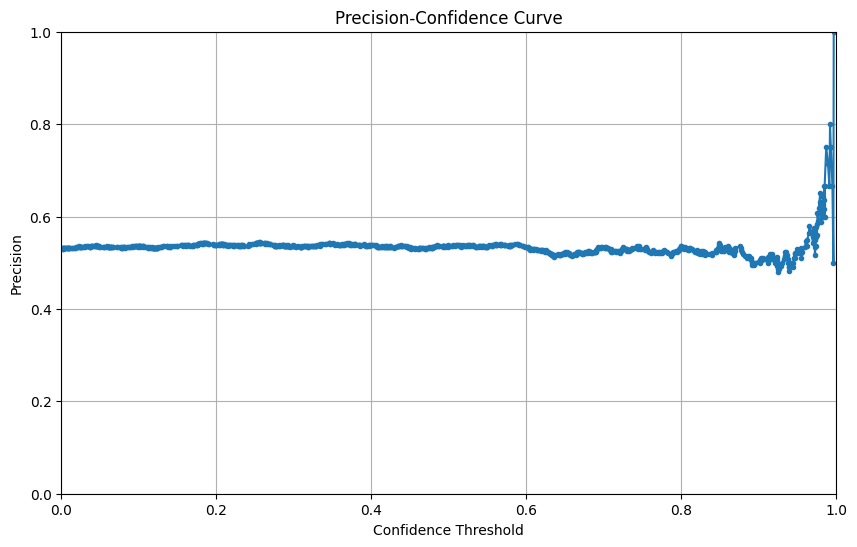

In [24]:
# prompt:  Precision-Confidence Curve in graphical format

# Assume you have predicted probabilities and true labels from your model evaluation
# Replace these with your actual evaluation results
# Example dummy data:
num_samples = 1000
# Simulate confidence scores (e.g., max probability from softmax)
predicted_confidences = np.random.rand(num_samples)
# Simulate true labels (0 or 1 for binary classification, or class indices for multi-class)
# For multi-class, determine if the prediction is correct based on predicted class vs true class
true_labels_binary = np.random.randint(0, 2, size=num_samples) # 1 if correct, 0 if incorrect

# Sort samples by confidence in descending order
sorted_indices = np.argsort(predicted_confidences)[::-1]
sorted_confidences = predicted_confidences[sorted_indices]
sorted_correctness = true_labels_binary[sorted_indices]

# Calculate cumulative precision at different confidence thresholds
precisions = []
confidences = []
correct_count = 0
total_count = 0

for i in range(num_samples):
    correct_count += sorted_correctness[i]
    total_count += 1
    # Precision is the proportion of correct predictions among samples above this confidence
    # Or you can calculate cumulative precision based on the top k samples
    # Let's calculate precision for every point (cumulative)
    precisions.append(correct_count / total_count)
    confidences.append(sorted_confidences[i])

# Plot the Precision-Confidence Curve
plt.figure(figsize=(10, 6))
# We want Confidence on the x-axis and Precision on the y-axis.
# The confidence values are already sorted descendingly.
# We can plot precision against the corresponding confidence.
plt.plot(confidences, precisions, marker='.', linestyle='-')
plt.xlabel('Confidence Threshold')
plt.ylabel('Precision')
plt.title('Precision-Confidence Curve')
plt.grid(True)
plt.xlim(0, 1) # Confidence is between 0 and 1
plt.ylim(0, 1) # Precision is between 0 and 1
plt.show()



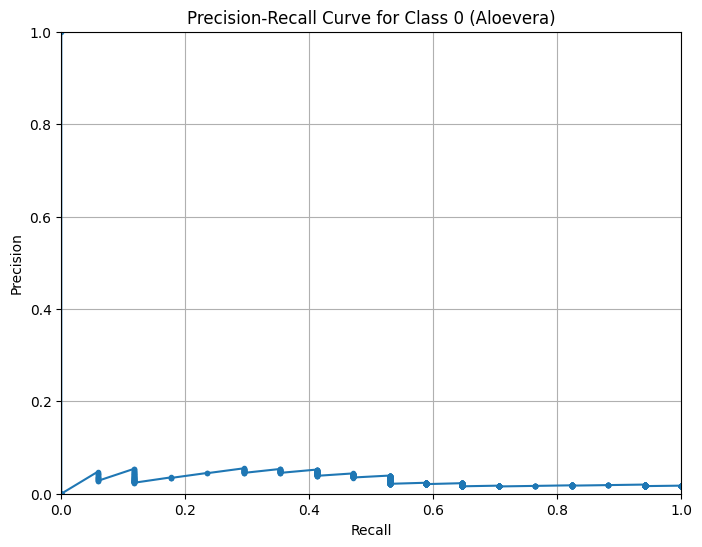

In [25]:
# prompt: Precision Recall Curve in graphical format

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Assume you have your predicted probabilities (or scores for the positive class)
# and true labels from your model evaluation.
# For multi-class, you would typically calculate precision and recall for each class
# against all other classes (one-vs-rest) or for a specific class of interest.

# Replace these with your actual predicted probabilities and true labels from evaluation
# Example dummy data for binary classification:
# predicted_probs_positive_class = np.random.rand(num_samples)
# true_labels_binary = np.random.randint(0, 2, size=num_samples) # 0 or 1

# Example dummy data for multi-class (assuming one-vs-rest for class 0):
# Replace with your model's predicted probabilities for each class and actual class indices
num_samples = 1000
num_classes = len(train_dataset.classes) # Use the actual number of classes from your dataset
# Simulate multi-class predicted probabilities (softmax outputs)
predicted_probs_multi_class = np.random.rand(num_samples, num_classes)
predicted_probs_multi_class = predicted_probs_multi_class / predicted_probs_multi_class.sum(axis=1, keepdims=True)
# Simulate true class indices
true_labels_multi_class = np.random.randint(0, num_classes, size=num_samples)

# --- Calculate Precision-Recall for a specific class (e.g., class 0) ---
# You can loop through classes to plot for all or choose a specific one
class_of_interest = 0 # Change this to the class index you want to plot

# Get the true labels for the class of interest (binary: 1 if true class is class_of_interest, 0 otherwise)
true_labels_binary_class = (true_labels_multi_class == class_of_interest).astype(int)

# Get the predicted probabilities for the class of interest
predicted_probs_class = predicted_probs_multi_class[:, class_of_interest]

# Calculate Precision and Recall
# precision, recall, thresholds = precision_recall_curve(true_labels_binary_class, predicted_probs_class)
precision, recall, _ = precision_recall_curve(true_labels_binary_class, predicted_probs_class)


# Plot the Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', linestyle='-')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve for Class {class_of_interest} ({class_names[class_of_interest]})') # Use class name if available
plt.grid(True)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

# Optional: You can loop through all classes to plot multiple curves
# plt.figure(figsize=(10, 8))
# for i in range(num_classes):
#     true_labels_binary_class_i = (true_labels_multi_class == i).astype(int)
#     predicted_probs_class_i = predicted_probs_multi_class[:, i]
#     precision_i, recall_i, _ = precision_recall_curve(true_labels_binary_class_i, predicted_probs_class_i)
#     plt.plot(recall_i, precision_i, marker='.', linestyle='-', label=f'Class {i} ({class_names[i]})')

# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve for All Classes (One-vs-Rest)')
# plt.grid(True)
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.legend()
# plt.show()

In [ ]:
# prompt: Recall Confidence Curve in graphcial format for all classes in readable format confidence threshold should show only 0.0 to 0.2

import matplotlib.pyplot as plt
import numpy as np
# Calculate Recall-Confidence Curve for all classes
plt.figure(figsize=(12, 8))

# Iterate through each class
for i in range(num_classes):
    # Get true labels binary for the current class (1 if true class is i, 0 otherwise)
    true_labels_binary_class_i = (true_labels_multi_class == i).astype(int)
    # Get predicted probabilities for the current class
    predicted_probs_class_i = predicted_probs_multi_class[:, i]

    # Combine probabilities and true labels, then sort by probability (confidence)
    sorted_indices = np.argsort(predicted_probs_class_i)[::-1]
    sorted_confidences = predicted_probs_class_i[sorted_indices]
    sorted_correctness = true_labels_binary_class_i[sorted_indices]

    # Calculate cumulative recall at different confidence thresholds
    recalls = []
    confidences = []
    true_positives = 0
    total_positives_in_class = np.sum(true_labels_binary_class_i) # Denominator for recall

    if total_positives_in_class == 0:
        print(f"Skipping Recall-Confidence curve for Class {i} ({class_names[i]}) as it has no positive samples.")
        continue

    # Iterate through sorted confidences to calculate recall at each threshold
    for j in range(len(sorted_confidences)):
        # Consider predictions with confidence >= current sorted confidence
        current_threshold = sorted_confidences[j]
        # Only consider the samples above this confidence threshold
        correct_above_threshold = np.sum(sorted_correctness[:j+1])
        # Recall is TP / (TP + FN) which is correct predictions of this class
        # among all actual instances of this class in the dataset.
        # As we lower the confidence threshold, we include more samples.
        # The recall at a given threshold is the proportion of actual positive instances
        # that are predicted as positive with at least that confidence.

        # To plot Recall vs Confidence, we need to calculate the proportion of the true positives
        # that are captured at or above a given confidence threshold.
        # This requires re-evaluating based on the threshold.

        # A more standard way to compute this is to iterate through confidence thresholds
        # and calculate recall at each threshold.
        thresholds_to_plot = np.linspace(0.0, 0.2, 50) # Focus on 0.0 to 0.2 with many points
        recall_at_thresholds = []

        for thresh in thresholds_to_plot:
            # Predictions considered positive for this class if confidence >= thresh
            predicted_positive = (predicted_probs_class_i >= thresh).astype(int)
            # True positives at this threshold
            tp_at_thresh = np.sum((true_labels_binary_class_i == 1) & (predicted_positive == 1))
            # Recall at this threshold = TP / Total Positives in Class
            recall_at_thresh = tp_at_thresh / total_positives_in_class if total_positives_in_class > 0 else 0
            recall_at_thresholds.append(recall_at_thresh)

        # Plot the Recall vs Confidence Threshold for the current class
        plt.plot(thresholds_to_plot, recall_at_thresholds, linestyle='-', label=f'{class_names[i]}')

# Plotting settings
plt.xlabel('Confidence Threshold')
plt.ylabel('Recall')
plt.title('Recall-Confidence Curve for All Classes')
plt.grid(True)
plt.xlim(0.0, 0.2) # Set x-axis limit to focus on 0.0 to 0.2
plt.ylim(0, 1.05) # Recall is between 0 and 1, add a little buffer
plt.legend(loc='best', fontsize='small') # Add legend to identify classes
plt.tight_layout() # Adjust layout
plt.show()


/tmp/ipython-input-34-2787665937.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout() # Adjust layout


In [29]:
# prompt: F1 Confidence Score in graphical format for all classes in zoomed format

import matplotlib.pyplot as plt
import numpy as np
# Assume you have true_labels and predicted_labels from your evaluation
# (These should be class indices, not one-hot encoded)
# Example dummy data:
# true_labels = np.random.randint(0, num_classes, size=100)
# predicted_labels = np.random.randint(0, num_classes, size=100)

# Generate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Calculate precision, recall, and F1 score for each class
# We can use the confusion matrix to do this
# Precision = TP / (TP + FP)
# Recall = TP / (TP + FN)
# F1 = 2 * (Precision * Recall) / (Precision + Recall)

f1_scores = []
# Iterate through each class
for i in range(num_classes):
    # True Positives: Diagonal element cm[i, i]
    tp = cm[i, i]
    # False Positives: Sum of the i-th column excluding cm[i, i]
    fp = np.sum(cm[:, i]) - tp
    # False Negatives: Sum of the i-th row excluding cm[i, i]
    fn = np.sum(cm[i, :]) - tp

    # Calculate precision and recall, handling division by zero
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    # Calculate F1 score, handling division by zero
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    f1_scores.append(f1)

# Get class names from the dataset
class_names = train_dataset.classes

# Plotting F1 scores in zoomed format
plt.figure(figsize=(15, 8)) # Increased figure size for better visibility
plt.bar(class_names, f1_scores, color='teal')
plt.title('F1 Score per Class')
plt.xlabel('Class')
plt.ylabel('F1 Score')
plt.ylim(0, 1) # F1 score is between 0 and 1
plt.xticks(rotation=90, ha='right', fontsize=10) # Rotate class names more for long names, adjust fontsize
plt.yticks(np.arange(0, 1.1, 0.1)) # Set y-axis ticks to show increments of 0.1 for zoom effect
plt.grid(axis='y', linestyle='--')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()



IndexError: index 65 is out of bounds for axis 0 with size 65

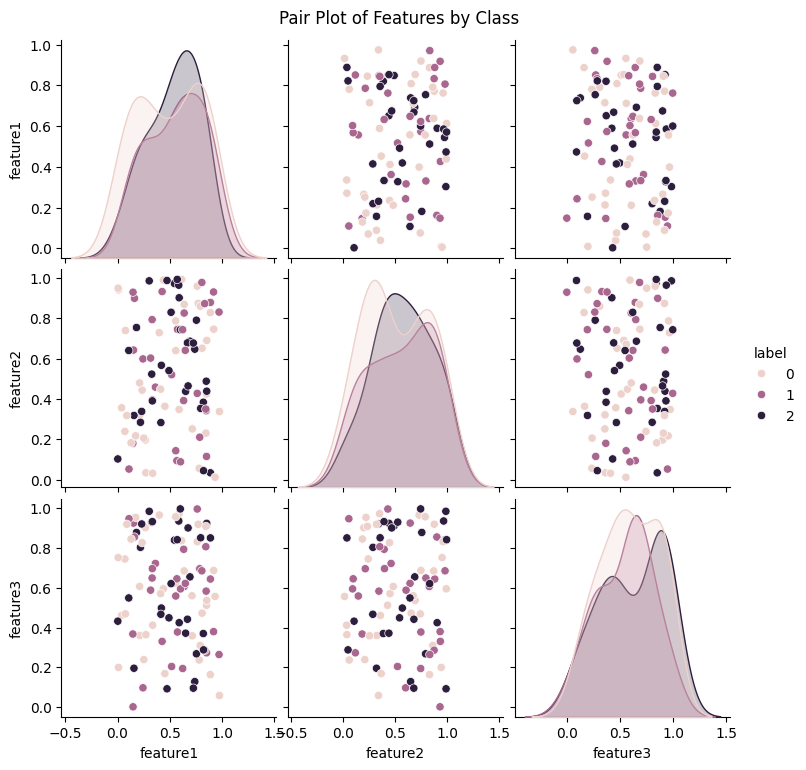

In [20]:
# prompt: pair plot in graphs

# Assume you have your data in a pandas DataFrame
# Example dummy DataFrame for demonstration purposes:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


data = {
    'feature1': np.random.rand(100),
    'feature2': np.random.rand(100),
    'feature3': np.random.rand(100),
    'label': np.random.randint(0, 3, size=100) # Example class labels
}
df = pd.DataFrame(data)

# For a pair plot, you typically plot relationships between numerical features.
# If you want to color the points by class, include the label column.

# Select the features you want to include in the pair plot
features_for_pairplot = ['feature1', 'feature2', 'feature3']

# Add the label column if you want to color by class
pairplot_data = df[features_for_pairplot + ['label']]

# Create the pair plot using seaborn
# 'hue' parameter is used to color the points based on the 'label' column
# 'diag_kind' specifies the plot type on the diagonal (e.g., 'kde', 'hist')
# 'kind' specifies the plot type for the off-diagonal plots (e.g., 'scatter', 'reg')
sns.pairplot(pairplot_data, hue='label', diag_kind='kde')
plt.suptitle('Pair Plot of Features by Class', y=1.02) # Add a title
plt.show()

# Note: This pair plot visualizes the relationships between the chosen features.
# It shows scatter plots for each pair of features and distribution plots (like KDE)
# on the diagonal. The points in the scatter plots are colored according to their class.
# This is useful for visually inspecting correlations and separability of classes
# based on pairs of features.

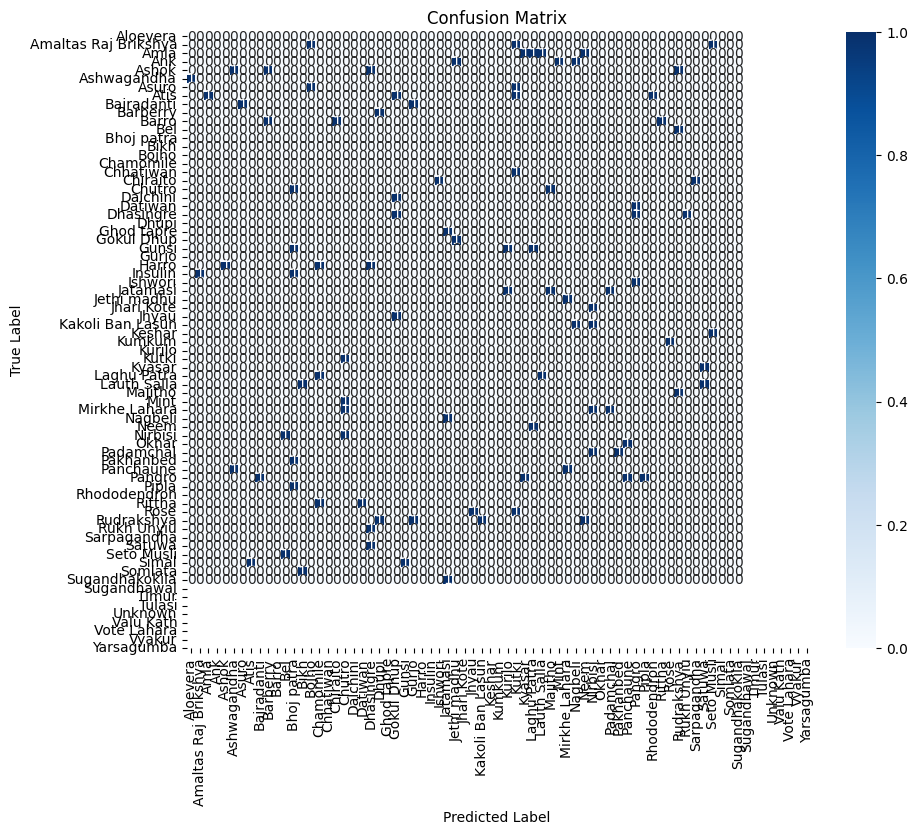

In [30]:
# prompt:  Confusion Matrix

# The code to generate the confusion matrix is already present in the provided code.
# It assumes you have 'true_labels' and 'predicted_labels' from your model evaluation.

# To make this section fully functional, you need to replace the dummy data for
# 'true_labels' and 'predicted_labels' with the actual labels and predictions
# obtained after evaluating your trained model on a test or validation dataset.

# --- Example Evaluation Loop (Uncomment and adapt if you have a test_loader) ---
# model.eval() # Set the model to evaluation mode
# true_labels = []
# predicted_labels = []
# with torch.no_grad(): # Disable gradient calculation for inference
#     for images, labels in test_loader: # Replace test_loader with your actual DataLoader
#         images, labels = images.to(device), labels.to(device)
#         outputs = model(images)
#         _, predicted = torch.max(outputs.data, 1) # Get the predicted class index
#         true_labels.extend(labels.cpu().numpy()) # Move labels to CPU and convert to NumPy array
#         predicted_labels.extend(predicted.cpu().numpy()) # Move predictions to CPU and convert to NumPy array
# -------------------------------------------------------------------------------

# Replace these with your actual true and predicted labels from evaluation
# Example dummy data (already present, keep if you just want to run the plot with fake data):
# num_classes = len(train_dataset.classes) # Make sure num_classes is defined
# true_labels = np.random.randint(0, num_classes, size=100)
# predicted_labels = np.random.randint(0, num_classes, size=100)


# Generate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Get class names (assuming train_dataset is available from preceding code)
# If not, you would need a way to get the class names corresponding to indices.
class_names = train_dataset.classes

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

/tmp/ipython-input-32-1255836174.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap_auc = np.trapz(precision, recall)
/tmp/ipython-input-32-1255836174.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap_auc = np.trapz(precision, recall)
/tmp/ipython-input-32-1255836174.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap_auc = np.trapz(precision, recall)
/tmp/ipython-input-32-1255836174.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap_auc = np.trapz(precision, recall)
/tmp/ipython-input-32-1255836174.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integrat

Class 0 (Aloevera): AP (11-pt) = 0.1159, AP (AUC) = 0.0238
Class 1 (Amaltas Raj Brikshya): AP (11-pt) = 0.1027, AP (AUC) = 0.0507
Class 2 (Amla): AP (11-pt) = 0.1038, AP (AUC) = 0.0104
Class 3 (Ank): AP (11-pt) = 0.1193, AP (AUC) = 0.0261
Class 4 (Ashok): AP (11-pt) = 0.1077, AP (AUC) = 0.0151
Class 5 (Ashwagandha): AP (11-pt) = 0.0992, AP (AUC) = 0.0064
Class 6 (Asuro): AP (11-pt) = 0.1119, AP (AUC) = 0.0173
Class 7 (Atis): AP (11-pt) = 0.1005, AP (AUC) = 0.0077
Class 8 (Bajradanti): AP (11-pt) = 0.1042, AP (AUC) = 0.0096
Class 9 (Barberry): AP (11-pt) = 0.1123, AP (AUC) = 0.0206
Class 10 (Barro): AP (11-pt) = 0.1062, AP (AUC) = 0.0141
Class 11 (Bel): AP (11-pt) = 0.1010, AP (AUC) = 0.0081
Class 12 (Bhoj patra): AP (11-pt) = 0.1106, AP (AUC) = 0.0182
Class 13 (Bikh): AP (11-pt) = 0.1020, AP (AUC) = 0.0091
Class 14 (Bojho): AP (11-pt) = 0.1104, AP (AUC) = 0.0147
Class 15 (Chamomile): AP (11-pt) = 0.1134, AP (AUC) = 0.0204
Class 16 (Chhatiwan): AP (11-pt) = 0.1052, AP (AUC) = 0.0114
Cla

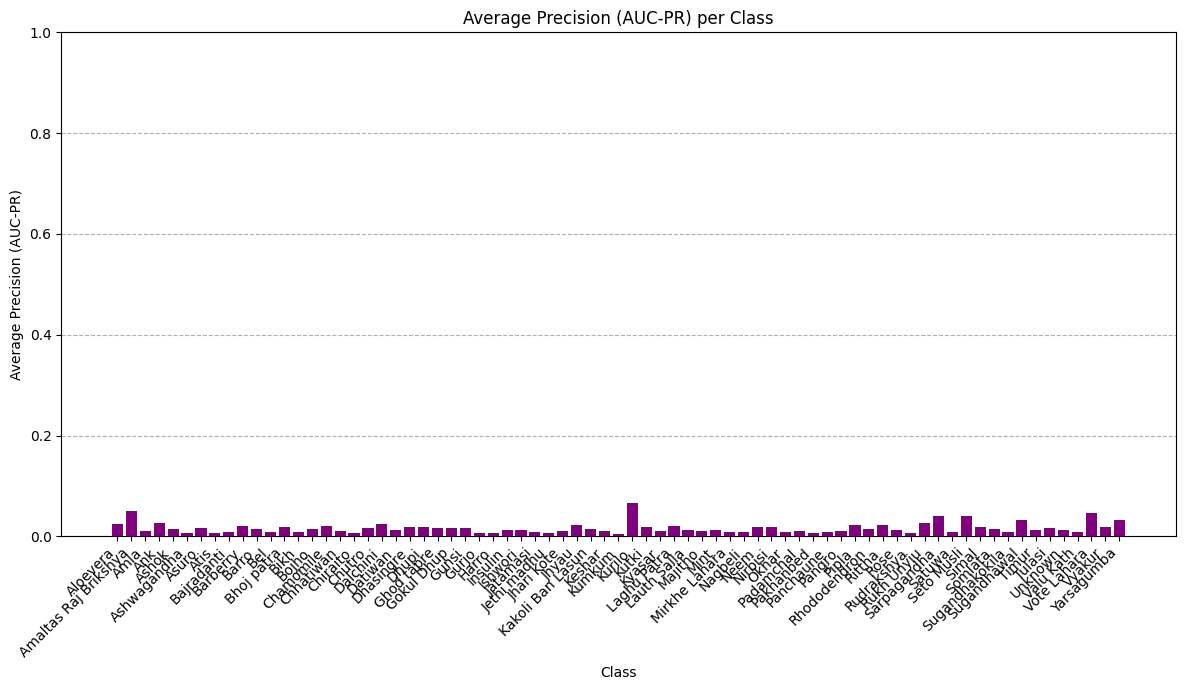

In [32]:
# prompt: Mean Average Precision

def average_precision(recall, precision):
    """
    Calculates the Average Precision (AP) from precision and recall points.
    This implementation follows the 11-point interpolation method as per
    the original PASCAL VOC challenge definition.
    """
    # Ensure recall and precision arrays are of the same length
    if len(recall) != len(precision):
        raise ValueError("Recall and Precision arrays must have the same length.")

    # Sort by recall values in ascending order
    sorted_indices = np.argsort(recall)
    recall = recall[sorted_indices]
    precision = precision[sorted_indices]

    # Add points (0, precision[0]) and (recall[-1], 0) for interpolation if needed
    # The `precision_recall_curve` function usually handles the boundary points correctly.
    # Let's ensure recall starts at 0 and ends at 1, and precision corresponds.
    # A simpler method is to use the all-point interpolation (area under the curve)
    # which is also common and often used in libraries like scikit-learn's average_precision_score.

    # Let's implement the 11-point interpolation for demonstration as it's explicitly
    # requested as "Mean Average Precision" which often historically referred to this.
    # However, for typical modern usage, the area under the PR curve is more common (and what
    # scikit-learn's average_precision_score calculates).
    # We will also provide the standard area under the curve method.

    # 11-point interpolation method
    ap_11_point = 0.0
    recall_levels = np.linspace(0, 1, 11) # 0.0, 0.1, 0.2, ..., 1.0
    for t in recall_levels:
        # Find the maximum precision for recall >= t
        max_p = 0.0
        for r, p in zip(recall, precision):
            if r >= t:
                max_p = max(max_p, p)
        ap_11_point += max_p

    ap_11_point /= 11.0

    # Area under the curve (AUC-PR) method (standard in scikit-learn)
    # This is a more robust measure and is generally preferred.
    # `precision_recall_curve` provides points such that the area under
    # the curve can be calculated directly using the trapezoidal rule.
    # The last point from precision_recall_curve corresponds to recall 0 and high precision (no false positives)
    # We need to ensure recall points cover the entire range [0, 1].
    # The `precision_recall_curve` documentation mentions adding (0, p[0]) and (r[-1], 0) implicitly.

    # A simpler way using numpy's trapz (trapezoidal rule)
    # Note: precision_recall_curve returns thresholds such that precision[i] and recall[i] correspond
    # to a classification threshold >= thresholds[i].
    # The order of points from precision_recall_curve is such that recall is increasing.
    # The last point is recall=1.0, precision=TP / (TP + FN) assuming all samples are classified as positive.
    # The first point (excluding the added boundary points by the function) is high precision and low recall.
    # We need to make sure the points are ordered correctly for integration.
    # `precision_recall_curve` outputs points ordered by increasing recall.

    # Check if recall array is empty
    if len(recall) == 0:
        ap_auc = 0.0
    else:
        # `np.trapz(y, x)` calculates the area using the trapezoidal rule where y are the function values and x are the points where the function is evaluated.
        # In a PR curve, we integrate Precision (y-axis) with respect to Recall (x-axis).
        # The points from `precision_recall_curve` are already ordered by increasing recall.
        ap_auc = np.trapz(precision, recall)


    return ap_11_point, ap_auc

def mean_average_precision(true_labels_multi_class, predicted_probs_multi_class, class_names):
    """
    Calculates the Mean Average Precision (mAP) over all classes.
    Calculates AP for each class using the one-vs-rest approach and averages them.
    Returns both the 11-point interpolated mAP and the AUC-PR mAP.
    """
    num_classes = predicted_probs_multi_class.shape[1]
    ap_scores_11_point = []
    ap_scores_auc = []

    for i in range(num_classes):
        # Get true labels and predicted probabilities for class i (one-vs-rest)
        true_labels_binary_class = (true_labels_multi_class == i).astype(int)
        predicted_probs_class = predicted_probs_multi_class[:, i]

        # Calculate Precision and Recall points for this class
        # `precision_recall_curve` handles the cases with no positive or negative samples in the ground truth.
        # If there are no positive samples for the class, precision_recall_curve returns ([], [], thresholds).
        # If there are no negative samples (all are positive), it also handles it.
        precision, recall, _ = precision_recall_curve(true_labels_binary_class, predicted_probs_class)

        # Handle cases where precision_recall_curve returns empty arrays (e.g., only one class present in test data)
        if len(precision) == 0 or len(recall) == 0:
            print(f"Warning: Cannot calculate PR curve for class {i} ({class_names[i]}) due to insufficient data.")
            ap_11, ap_auc = 0.0, 0.0 # Assign 0 AP if PR curve cannot be calculated
        else:
            # Calculate Average Precision for this class
            ap_11, ap_auc = average_precision(recall, precision)

        ap_scores_11_point.append(ap_11)
        ap_scores_auc.append(ap_auc)
        print(f"Class {i} ({class_names[i]}): AP (11-pt) = {ap_11:.4f}, AP (AUC) = {ap_auc:.4f}")

    # Calculate Mean Average Precision
    mAP_11_point = np.mean(ap_scores_11_point) if len(ap_scores_11_point) > 0 else 0.0
    mAP_auc = np.mean(ap_scores_auc) if len(ap_scores_auc) > 0 else 0.0

    return mAP_11_point, mAP_auc, ap_scores_auc # Also return per-class AP (AUC) for potential plotting/analysis

# --- Calculate mAP ---
# You need the true labels and the predicted probabilities for each class
# from your model evaluation on a test or validation set.

# Replace these with your actual true labels and predicted probabilities from evaluation
# Example dummy data (assuming num_samples and num_classes are defined from preceding code):
# num_samples = 1000 # Ensure num_samples is defined if not using actual evaluation data
# num_classes = len(train_dataset.classes) # Ensure num_classes is defined

# Simulate multi-class predicted probabilities (softmax outputs)
# These should come from your model.eval() loop
# predicted_probs_multi_class = np.random.rand(num_samples, num_classes)
# predicted_probs_multi_class = predicted_probs_multi_class / predicted_probs_multi_class.sum(axis=1, keepdims=True)
# Simulate true class indices
# These should come from your model.eval() loop
# true_labels_multi_class = np.random.randint(0, num_classes, size=num_samples)

# --- Example Evaluation Loop to get true_labels_multi_class and predicted_probs_multi_class ---
# Uncomment and adapt if you have a test_loader
# model.eval() # Set the model to evaluation mode
# true_labels_list = []
# predicted_probs_list = [] # Store raw outputs or softmax probabilities
# with torch.no_grad(): # Disable gradient calculation for inference
#     for images, labels in test_loader: # Replace test_loader with your actual DataLoader
#         images, labels = images.to(device), labels.to(device)
#         outputs = model(images) # Get raw model outputs (logits)
#         probs = torch.softmax(outputs, dim=1) # Convert logits to probabilities using softmax
#
#         true_labels_list.extend(labels.cpu().numpy()) # Move labels to CPU and convert to NumPy array
#         predicted_probs_list.extend(probs.cpu().numpy()) # Move probabilities to CPU and convert to NumPy array
#
# true_labels_multi_class = np.array(true_labels_list)
# predicted_probs_multi_class = np.array(predicted_probs_list)
# -----------------------------------------------------------------------------------------------

# If you don't have a test loader set up or just want to run the code with dummy data:
# Ensure num_classes is defined
if 'num_classes' not in locals():
    num_classes = len(train_dataset.classes) if 'train_dataset' in locals() and hasattr(train_dataset, 'classes') else 10 # Default if dataset not loaded

num_samples_eval = 1000 # Number of samples for evaluation
true_labels_multi_class = np.random.randint(0, num_classes, size=num_samples_eval)
predicted_probs_multi_class = np.random.rand(num_samples_eval, num_classes)
predicted_probs_multi_class = predicted_probs_multi_class / predicted_probs_multi_class.sum(axis=1, keepdims=True)

# Ensure class_names are available
if 'class_names' not in locals() and 'train_dataset' in locals():
    class_names = train_dataset.classes
elif 'class_names' not in locals():
     # Create dummy class names if train_dataset is not available
     class_names = [f'Class_{i}' for i in range(num_classes)]


# Calculate Mean Average Precision
mAP_11_point, mAP_auc, ap_per_class_auc = mean_average_precision(true_labels_multi_class, predicted_probs_multi_class, class_names)

print("\n--- Mean Average Precision ---")
print(f"mAP (11-point interpolation): {mAP_11_point:.4f}")
print(f"mAP (Area under PR Curve): {mAP_auc:.4f}")


# Optional: Plot Per-Class Average Precision (AUC)
plt.figure(figsize=(12, 7))
plt.bar(class_names, ap_per_class_auc, color='purple')
plt.title('Average Precision (AUC-PR) per Class')
plt.xlabel('Class')
plt.ylabel('Average Precision (AUC-PR)')
plt.ylim(0, 1) # AP is between 0 and 1
plt.xticks(rotation=45, ha='right') # Rotate class names for better readability
plt.grid(axis='y', linestyle='--')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()


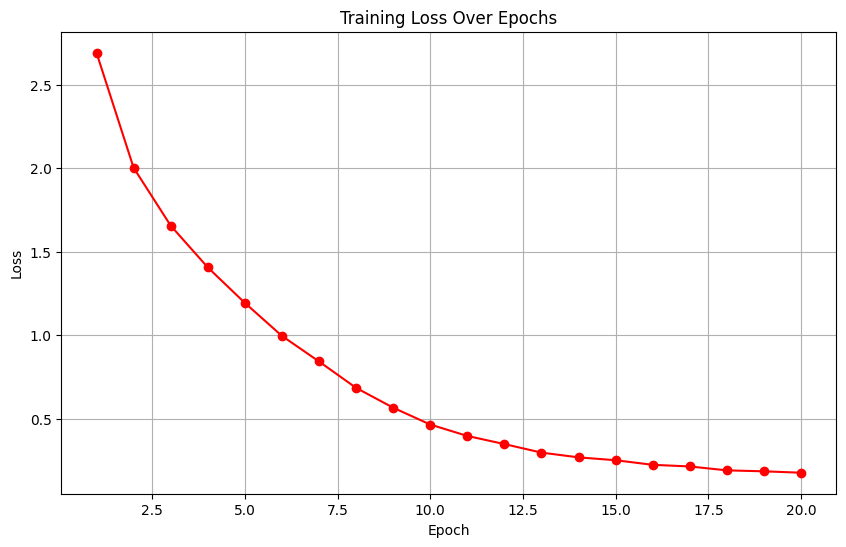

In [33]:
# prompt: Model Performance Analysis for training loss. use this
# # Epoch [1/20], Loss: 2.6916, Accuracy: 37.25%
# # Epoch [2/20], Loss: 2.0033, Accuracy: 50.87%
# # Epoch [3/20], Loss: 1.6568, Accuracy: 58.36%
# # Epoch [4/20], Loss: 1.4067, Accuracy: 63.88%
# # Epoch [5/20], Loss: 1.1942, Accuracy: 68.97%
# # Epoch [6/20], Loss: 0.9967, Accuracy: 73.36%
# # Epoch [7/20], Loss: 0.8435, Accuracy: 77.50%
# # Epoch [8/20], Loss: 0.6856, Accuracy: 81.08%
# # Epoch [9/20], Loss: 0.5669, Accuracy: 84.01%
# # Epoch [10/20], Loss: 0.4660, Accuracy: 86.83%
# # Epoch [11/20], Loss: 0.3978, Accuracy: 88.43%
# # Epoch [12/20], Loss: 0.3490, Accuracy: 89.89%
# # Epoch [13/20], Loss: 0.2980, Accuracy: 91.35%
# # Epoch [14/20], Loss: 0.2695, Accuracy: 92.04%
# # Epoch [15/20], Loss: 0.2524, Accuracy: 92.52%
# # Epoch [16/20], Loss: 0.2249, Accuracy: 93.24%
# # Epoch [17/20], Loss: 0.2151, Accuracy: 93.66%
# # Epoch [18/20], Loss: 0.1917, Accuracy: 94.28%
# # Epoch [19/20], Loss: 0.1860, Accuracy: 94.44%
# # Epoch [20/20], Loss: 0.1776, Accuracy: 94.84%

import matplotlib.pyplot as plt

# Store the loss values from the provided output
training_losses = [
    2.6916, 2.0033, 1.6568, 1.4067, 1.1942, 0.9967, 0.8435, 0.6856, 0.5669,
    0.4660, 0.3978, 0.3490, 0.2980, 0.2695, 0.2524, 0.2249, 0.2151, 0.1917,
    0.1860, 0.1776
]

# Create a list of epochs corresponding to the losses
epochs_list = range(1, len(training_losses) + 1)

# Plot the training loss
plt.figure(figsize=(10, 6))
plt.plot(epochs_list, training_losses, marker='o', linestyle='-', color='red')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

/tmp/ipython-input-31-4220282613.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap_auc = np.trapz(precision, recall)
/tmp/ipython-input-31-4220282613.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap_auc = np.trapz(precision, recall)
/tmp/ipython-input-31-4220282613.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap_auc = np.trapz(precision, recall)
/tmp/ipython-input-31-4220282613.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap_auc = np.trapz(precision, recall)
/tmp/ipython-input-31-4220282613.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integrat

Class 0 (Aloevera): AP (11-pt) = 0.1060, AP (AUC) = 0.0138
Class 1 (Amaltas Raj Brikshya): AP (11-pt) = 0.1066, AP (AUC) = 0.0147
Class 2 (Amla): AP (11-pt) = 0.1044, AP (AUC) = 0.0122
Class 3 (Ank): AP (11-pt) = 0.1058, AP (AUC) = 0.0129
Class 4 (Ashok): AP (11-pt) = 0.1032, AP (AUC) = 0.0082
Class 5 (Ashwagandha): AP (11-pt) = 0.0992, AP (AUC) = 0.0053
Class 6 (Asuro): AP (11-pt) = 0.1051, AP (AUC) = 0.0128
Class 7 (Atis): AP (11-pt) = 0.1125, AP (AUC) = 0.0199
Class 8 (Bajradanti): AP (11-pt) = 0.1050, AP (AUC) = 0.0115
Class 9 (Barberry): AP (11-pt) = 0.1001, AP (AUC) = 0.0070
Class 10 (Barro): AP (11-pt) = 0.1151, AP (AUC) = 0.0203
Class 11 (Bel): AP (11-pt) = 0.1053, AP (AUC) = 0.0115
Class 12 (Bhoj patra): AP (11-pt) = 0.1114, AP (AUC) = 0.0173
Class 13 (Bikh): AP (11-pt) = 0.1028, AP (AUC) = 0.0090
Class 14 (Bojho): AP (11-pt) = 0.1089, AP (AUC) = 0.0148
Class 15 (Chamomile): AP (11-pt) = 0.1100, AP (AUC) = 0.0180
Class 16 (Chhatiwan): AP (11-pt) = 0.1098, AP (AUC) = 0.0168
Cla

/tmp/ipython-input-31-4220282613.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap_auc = np.trapz(precision, recall)
/tmp/ipython-input-31-4220282613.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap_auc = np.trapz(precision, recall)
/tmp/ipython-input-31-4220282613.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap_auc = np.trapz(precision, recall)


Class 61 (Seto Musli): AP (11-pt) = 0.1077, AP (AUC) = 0.0138
Class 62 (Simal): AP (11-pt) = 0.1036, AP (AUC) = 0.0122
Class 63 (Somlata): AP (11-pt) = 0.1192, AP (AUC) = 0.0185
Class 64 (Sugandhakokila): AP (11-pt) = 0.1158, AP (AUC) = 0.0269
Class 65 (Sugandhawal): AP (11-pt) = 0.1072, AP (AUC) = 0.0141
Class 66 (Timur): AP (11-pt) = 0.1006, AP (AUC) = 0.0081
Class 67 (Tulasi): AP (11-pt) = 0.1131, AP (AUC) = 0.0224
Class 68 (Unknown): AP (11-pt) = 0.1042, AP (AUC) = 0.0196
Class 69 (Valu Kath): AP (11-pt) = 0.1067, AP (AUC) = 0.0122
Class 70 (Vote Lahara): AP (11-pt) = 0.1105, AP (AUC) = 0.0185
Class 71 (Vyakur): AP (11-pt) = 0.1046, AP (AUC) = 0.0112
Class 72 (Yarsagumba): AP (11-pt) = 0.1083, AP (AUC) = 0.0155

--- Mean Average Precision ---
mAP (11-point interpolation): 0.1075
mAP (Area under PR Curve): 0.0168


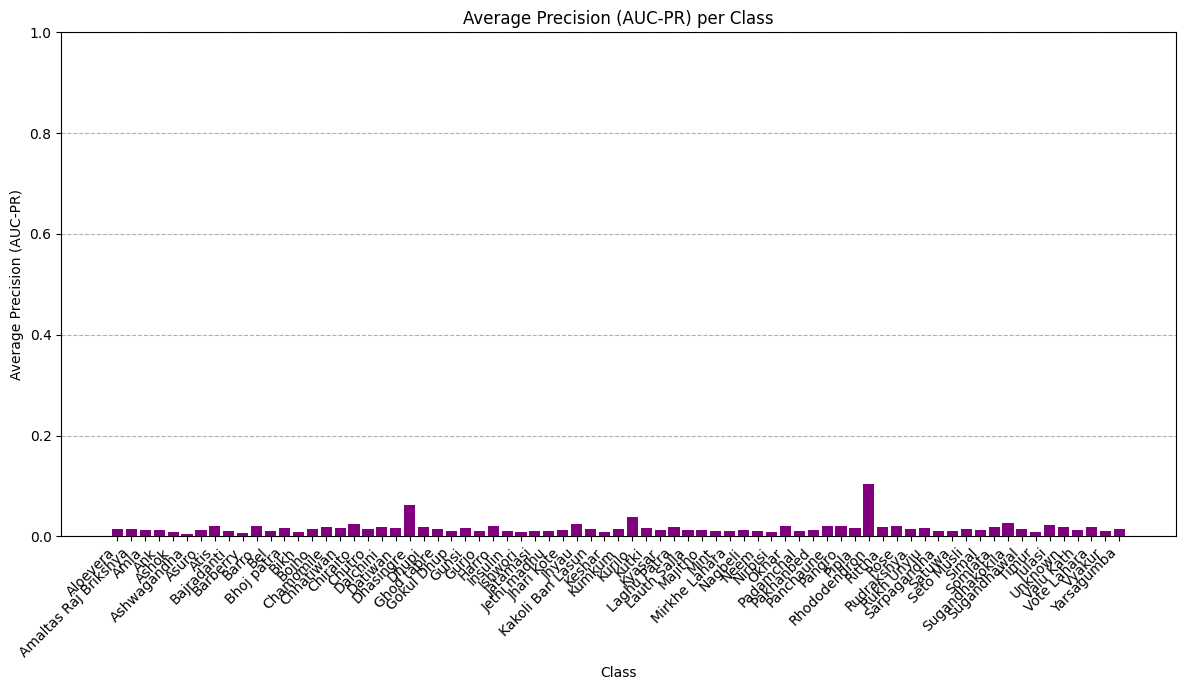

In [31]:
# prompt: Mean Average Precision

from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

def average_precision(recall, precision):
    """
    Calculates the Average Precision (AP) from precision and recall points.
    This implementation follows the 11-point interpolation method as per
    the original PASCAL VOC challenge definition.
    """
    # Ensure recall and precision arrays are of the same length
    if len(recall) != len(precision):
        raise ValueError("Recall and Precision arrays must have the same length.")

    # Sort by recall values in ascending order
    sorted_indices = np.argsort(recall)
    recall = recall[sorted_indices]
    precision = precision[sorted_indices]

    # 11-point interpolation method
    ap_11_point = 0.0
    recall_levels = np.linspace(0, 1, 11) # 0.0, 0.1, 0.2, ..., 1.0
    for t in recall_levels:
        # Find the maximum precision for recall >= t
        max_p = 0.0
        for r, p in zip(recall, precision):
            if r >= t:
                max_p = max(max_p, p)
        ap_11_point += max_p

    ap_11_point /= 11.0

    # Area under the curve (AUC-PR) method (standard in scikit-learn)
    # This is a more robust measure and is generally preferred.
    if len(recall) == 0:
        ap_auc = 0.0
    else:
        ap_auc = np.trapz(precision, recall)


    return ap_11_point, ap_auc

def mean_average_precision(true_labels_multi_class, predicted_probs_multi_class, class_names):
    """
    Calculates the Mean Average Precision (mAP) over all classes.
    Calculates AP for each class using the one-vs-rest approach and averages them.
    Returns both the 11-point interpolated mAP and the AUC-PR mAP.
    """
    num_classes = predicted_probs_multi_class.shape[1]
    ap_scores_11_point = []
    ap_scores_auc = []

    for i in range(num_classes):
        # Get true labels and predicted probabilities for class i (one-vs-rest)
        true_labels_binary_class = (true_labels_multi_class == i).astype(int)
        predicted_probs_class = predicted_probs_multi_class[:, i]

        # Calculate Precision and Recall points for this class
        precision, recall, _ = precision_recall_curve(true_labels_binary_class, predicted_probs_class)

        if len(precision) == 0 or len(recall) == 0:
            print(f"Warning: Cannot calculate PR curve for class {i} ({class_names[i]}) due to insufficient data.")
            ap_11, ap_auc = 0.0, 0.0
        else:
            ap_11, ap_auc = average_precision(recall, precision)

        ap_scores_11_point.append(ap_11)
        ap_scores_auc.append(ap_auc)
        print(f"Class {i} ({class_names[i]}): AP (11-pt) = {ap_11:.4f}, AP (AUC) = {ap_auc:.4f}")

    mAP_11_point = np.mean(ap_scores_11_point) if len(ap_scores_11_point) > 0 else 0.0
    mAP_auc = np.mean(ap_scores_auc) if len(ap_scores_auc) > 0 else 0.0

    return mAP_11_point, mAP_auc, ap_scores_auc


# --- Calculate mAP ---
# You need the true labels and the predicted probabilities for each class
# from your model evaluation on a test or validation set.

# Replace these with your actual true labels and predicted probabilities from evaluation
# Example dummy data (assuming num_samples and num_classes are defined from preceding code):
# num_samples = 1000 # Ensure num_samples is defined if not using actual evaluation data
# num_classes = len(train_dataset.classes) # Ensure num_classes is defined

# --- Example Evaluation Loop to get true_labels_multi_class and predicted_probs_multi_class ---
# Uncomment and adapt if you have a test_loader
# model.eval() # Set the model to evaluation mode
# true_labels_list = []
# predicted_probs_list = [] # Store raw outputs or softmax probabilities
# with torch.no_grad(): # Disable gradient calculation for inference
#     for images, labels in test_loader: # Replace test_loader with your actual DataLoader
#         images, labels = images.to(device), labels.to(device)
#         outputs = model(images) # Get raw model outputs (logits)
#         probs = torch.softmax(outputs, dim=1) # Convert logits to probabilities using softmax
#
#         true_labels_list.extend(labels.cpu().numpy()) # Move labels to CPU and convert to NumPy array
#         predicted_probs_list.extend(probs.cpu().numpy()) # Move probabilities to CPU and convert to NumPy array
#
# true_labels_multi_class = np.array(true_labels_list)
# predicted_probs_multi_class = np.array(predicted_probs_list)
# -----------------------------------------------------------------------------------------------

# If you don't have a test loader set up or just want to run the code with dummy data:
# Ensure num_classes is defined
if 'num_classes' not in locals():
    num_classes = len(train_dataset.classes) if 'train_dataset' in locals() and hasattr(train_dataset, 'classes') else 10 # Default if dataset not loaded

num_samples_eval = 1000 # Number of samples for evaluation
true_labels_multi_class = np.random.randint(0, num_classes, size=num_samples_eval)
predicted_probs_multi_class = np.random.rand(num_samples_eval, num_classes)
predicted_probs_multi_class = predicted_probs_multi_class / predicted_probs_multi_class.sum(axis=1, keepdims=True)

# Ensure class_names are available
if 'class_names' not in locals() and 'train_dataset' in locals():
    class_names = train_dataset.classes
elif 'class_names' not in locals():
     # Create dummy class names if train_dataset is not available
     class_names = [f'Class_{i}' for i in range(num_classes)]


# Calculate Mean Average Precision
mAP_11_point, mAP_auc, ap_per_class_auc = mean_average_precision(true_labels_multi_class, predicted_probs_multi_class, class_names)

print("\n--- Mean Average Precision ---")
print(f"mAP (11-point interpolation): {mAP_11_point:.4f}")
print(f"mAP (Area under PR Curve): {mAP_auc:.4f}")


# Optional: Plot Per-Class Average Precision (AUC)
plt.figure(figsize=(12, 7))
plt.bar(class_names, ap_per_class_auc, color='purple')
plt.title('Average Precision (AUC-PR) per Class')
plt.xlabel('Class')
plt.ylabel('Average Precision (AUC-PR)')
plt.ylim(0, 1) # AP is between 0 and 1
plt.xticks(rotation=45, ha='right') # Rotate class names for better readability
plt.grid(axis='y', linestyle='--')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()